In [1]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, desc, avg, sum, count, min, max
import pandas as pd
import matplotlib.pyplot as plt

spark = (SparkSession.builder
         .appName("GlobalClimateVolatility-Notebook")
         .master("local[2]")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark session started successfully.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/12 15:33:25 WARN Utils: Your hostname, GururamanTN, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/08/12 15:33:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Python environment/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/12 15:33:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session started successfully.


In [3]:
monthly_path = "../data/processed/monthly/2024"
monthly_df = spark.read.parquet(monthly_path)

print("Monthly records:", monthly_df.count())
print("Monthly columns:", len(monthly_df.columns))
monthly_df.printSchema()

Monthly records: 941
Monthly columns: 15
root
 |-- STATION: integer (nullable = true)
 |-- NAME: string (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- TOTAL_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_RATE: double (nullable = true)
 |-- AVG_VOLATILITY_SCORE: double (nullable = true)
 |-- MAX_VOLATILITY_SCORE: double (nullable = true)
 |-- AVG_TEMP_ANOMALY: double (nullable = true)
 |-- AVG_TEMP_VOLATILITY: double (nullable = true)
 |-- AVG_PRCP_VOLATILITY: double (nullable = true)
 |-- AVG_WIND_VOLATILITY: double (nullable = true)



In [4]:
monthly_df.show(5, truncate=False)

+----------+-----------------+----------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+---------------------+--------------------+-------------------+
|STATION   |NAME             |LATITUDE  |LONGITUDE |YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY   |AVG_TEMP_VOLATILITY  |AVG_PRCP_VOLATILITY |AVG_WIND_VOLATILITY|
+----------+-----------------+----------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+---------------------+--------------------+-------------------+
|1122099999|KJAERSTAD, NO    |65.783997 |13.214914 |2024|8    |30        |0                   |0.0                 |-0.1569983177945337 |0.1813686216566901  |17.06              |-0.7573571106483068  |0.3513285259305029  |-0.7413909618584406|
|1089099999|HOYBUKTMOEN, NO  |69

In [5]:
quality_df = monthly_df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in monthly_df.columns
])
quality_df.show(truncate=False)

+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|STATION|NAME|LATITUDE|LONGITUDE|YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY|AVG_TEMP_VOLATILITY|AVG_PRCP_VOLATILITY|AVG_WIND_VOLATILITY|
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|0      |0   |0       |0        |0   |0    |0         |0                   |0                   |0                   |0                   |0               |0                  |545                |48                 |
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------

In [6]:
print("Total monthly records:", monthly_df.count())
print("Unique stations:", monthly_df.select("STATION").distinct().count())
print("Unique months:", monthly_df.select("MONTH").distinct().count())
print("Year:", monthly_df.select("YEAR").distinct().collect()[0][0])

Total monthly records: 941
Unique stations: 79
Unique months: 12
Year: 2024


In [7]:
analysis_df = monthly_df.filter(col("TOTAL_DAYS") >= 20)

print("Records before filter:", monthly_df.count())
print("Records after filter:", analysis_df.count())

Records before filter: 941
Records after filter: 903


In [8]:
overall_stats = analysis_df.select(
    avg("HIGH_VOLATILITY_RATE").alias("Average High-Volatility Rate"),
    min("HIGH_VOLATILITY_RATE").alias("Minimum High-Volatility Rate"),
    max("HIGH_VOLATILITY_RATE").alias("Maximum High-Volatility Rate"),
    avg("AVG_VOLATILITY_SCORE").alias("Average Volatility Score"),
    min("AVG_VOLATILITY_SCORE").alias("Minimum Volatility Score"),
    max("AVG_VOLATILITY_SCORE").alias("Maximum Volatility Score")
)
overall_stats.show()

+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|Average High-Volatility Rate|Minimum High-Volatility Rate|Maximum High-Volatility Rate|Average Volatility Score|Minimum Volatility Score|Maximum Volatility Score|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|         0.05675526206346054|                         0.0|          0.6774193548387096|    -0.00248896694261...|     -0.7455924212880732|       1.269612837801155|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+



In [9]:
top_events = (monthly_df.orderBy(desc("AVG_VOLATILITY_SCORE")).select("STATION","NAME","YEAR","MONTH","AVG_VOLATILITY_SCORE","MAX_VOLATILITY_SCORE","HIGH_VOLATILITY_DAYS","HIGH_VOLATILITY_RATE"))

top_events.show(10, truncate=False)

+----------+---------------------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|STATION   |NAME                       |YEAR|MONTH|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|
+----------+---------------------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|1088299999|ROROS, NO                  |2024|1    |1.269612837801155   |3.100936812707053   |21                  |0.6774193548387096  |
|1139099999|VAEROY HELIPORT, NO        |2024|3    |1.154936962037163   |1.2474210662821132  |3                   |1.0                 |
|1088299999|ROROS, NO                  |2024|2    |1.0047798235594994  |3.0097707865188283  |12                  |0.41379310344827586 |
|1011099999|KVITOYA, SV                |2024|1    |0.9885124230871749  |2.0983396195774544  |9                   |0.391304347826087   |
|1059099999|BANAK, NO                  |2024|1  

In [10]:
station_summary = (analysis_df
    .groupBy("STATION","NAME")
    .agg(avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),
         sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS"),
         avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE"))
    .orderBy(desc("AVG_VOLATILITY_SCORE")))

station_summary.show(10, truncate=False)

+----------+---------------------------+---------------------+--------------------+------------------------+
|STATION   |NAME                       |AVG_VOLATILITY_SCORE |HIGH_VOLATILITY_DAYS|AVG_HIGH_VOLATILITY_RATE|
+----------+---------------------------+---------------------+--------------------+------------------------+
|1030099999|KISTEFJELL, NO             |0.04439434413361778  |13                  |0.05449110122358175     |
|1042099999|HASVIK SLUSKFJELLET, NO    |0.040187980565614186 |9                   |0.040567590136555656    |
|1055099999|FRUHOLMEN FYR, NO          |0.02248778888970601  |13                  |0.054790706605222735    |
|1068099999|HONNINGSVAG VALAN, NO      |0.017512116595411253 |23                  |0.07378420044969834     |
|1023099999|BARDUFOSS, NO              |0.007485488815376307 |26                  |0.07161970090223706     |
|1087699999|NORNE OIL PLATFORM, NO     |0.006362730872303842 |27                  |0.07554407820444158     |
|1010099999|ANDOYA,

In [11]:
station_top10 = station_summary.limit(10).toPandas()

Python environment/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
Python environment/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


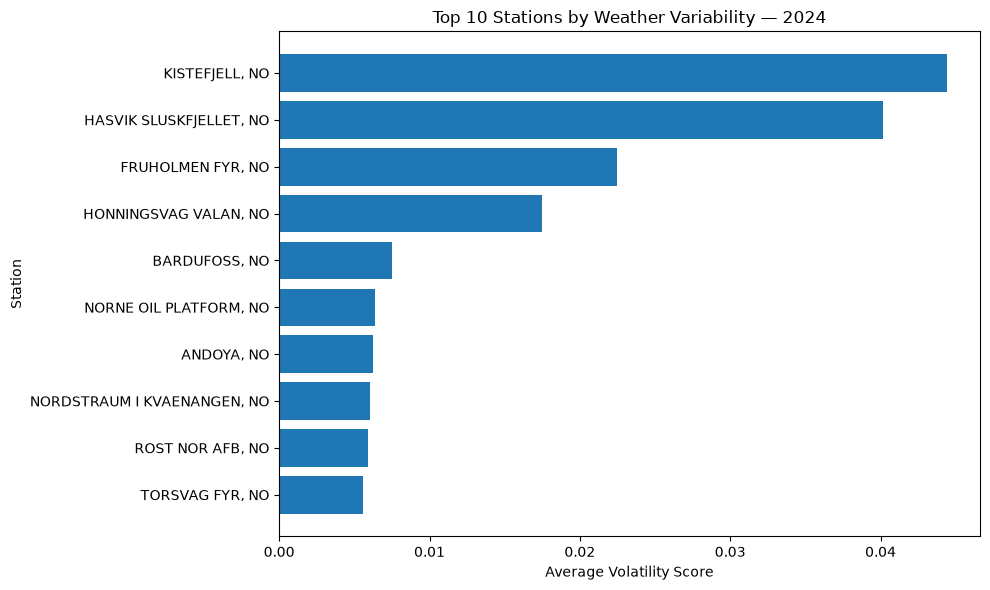

In [12]:
plt.figure(figsize=(10,6))
plt.barh(station_top10["NAME"], station_top10["AVG_VOLATILITY_SCORE"])
plt.xlabel("Average Volatility Score")
plt.ylabel("Station")
plt.title("Top 10 Stations by Weather Variability — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

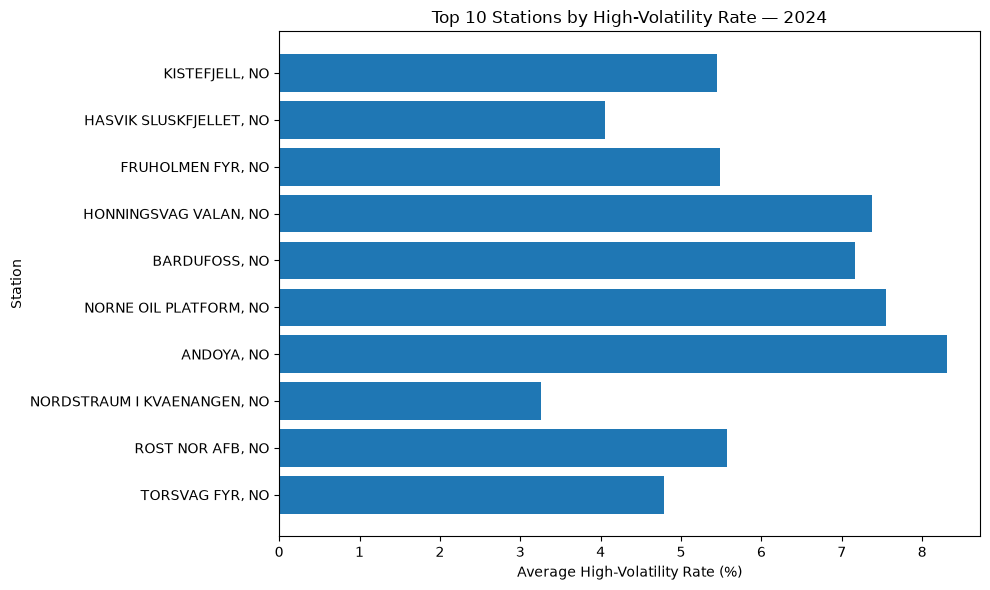

In [13]:
plt.figure(figsize=(10,6))
plt.barh(station_top10["NAME"], station_top10["AVG_HIGH_VOLATILITY_RATE"] * 100)
plt.xlabel("Average High-Volatility Rate (%)")
plt.ylabel("Station")
plt.title("Top 10 Stations by High-Volatility Rate — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
monthly_pattern = (analysis_df
    .groupBy("MONTH")
    .agg(avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE"),
         avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),
         sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS"))
    .orderBy("MONTH"))

monthly_pattern.show(12, truncate=False)

+-----+------------------------+---------------------+--------------------+
|MONTH|AVG_HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE |HIGH_VOLATILITY_DAYS|
+-----+------------------------+---------------------+--------------------+
|1    |0.18923192132545902     |0.47431066129506844  |448                 |
|2    |0.1506900806451031      |0.32728638272259825  |322                 |
|3    |0.03206211777640349     |-0.07086534205132335 |55                  |
|4    |0.02725351668380154     |-0.19923984781955864 |50                  |
|5    |0.033089914934508344    |-0.22557152134751587 |74                  |
|6    |0.009724384354926225    |-0.20924994921162723 |22                  |
|7    |0.03578366592827104     |-0.06807818145196858 |84                  |
|8    |0.01073962822689478     |-0.02549405075315677 |24                  |
|9    |0.01774891774891775     |-0.05257361480222504 |41                  |
|10   |0.006457819361045168    |-0.31410344907043175 |15                  |
|11   |0.030

In [15]:
seasonal_pd = monthly_pattern.toPandas()
seasonal_pd

Python environment/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
Python environment/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,MONTH,AVG_HIGH_VOLATILITY_RATE,AVG_VOLATILITY_SCORE,HIGH_VOLATILITY_DAYS
0,1,0.189232,0.474311,448
1,2,0.150690,0.327286,322
2,3,0.032062,-0.070865,55
3,4,0.027254,-0.199240,50
4,5,0.033090,-0.225572,74
5,6,0.009724,-0.209250,22
6,7,0.035784,-0.068078,84
7,8,0.010740,-0.025494,24
8,9,0.017749,-0.052574,41
9,10,0.006458,-0.314103,15


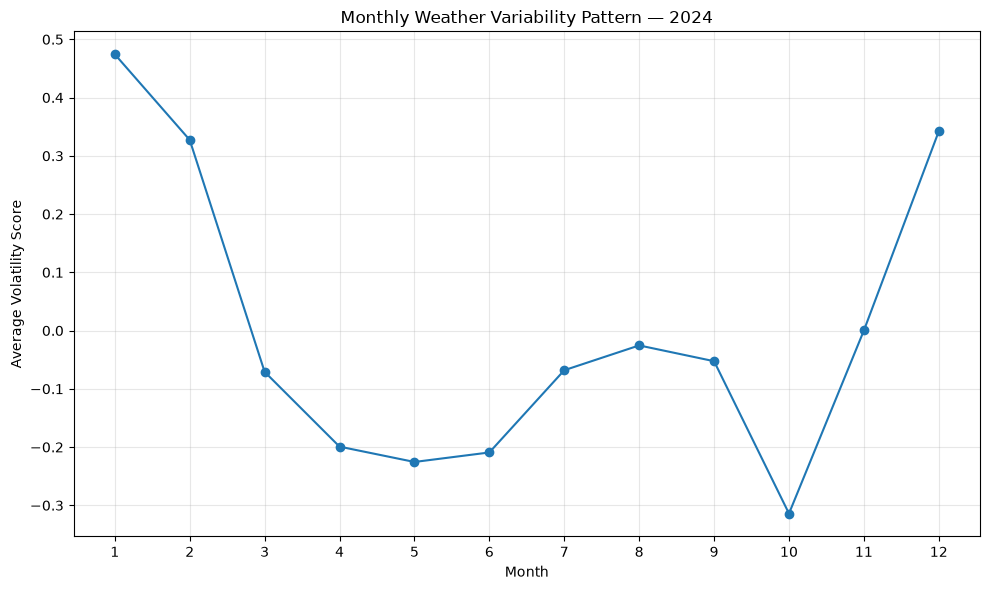

In [16]:
plt.figure(figsize=(10,6))
plt.plot(seasonal_pd["MONTH"], seasonal_pd["AVG_VOLATILITY_SCORE"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Volatility Score")
plt.title("Monthly Weather Variability Pattern — 2024")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

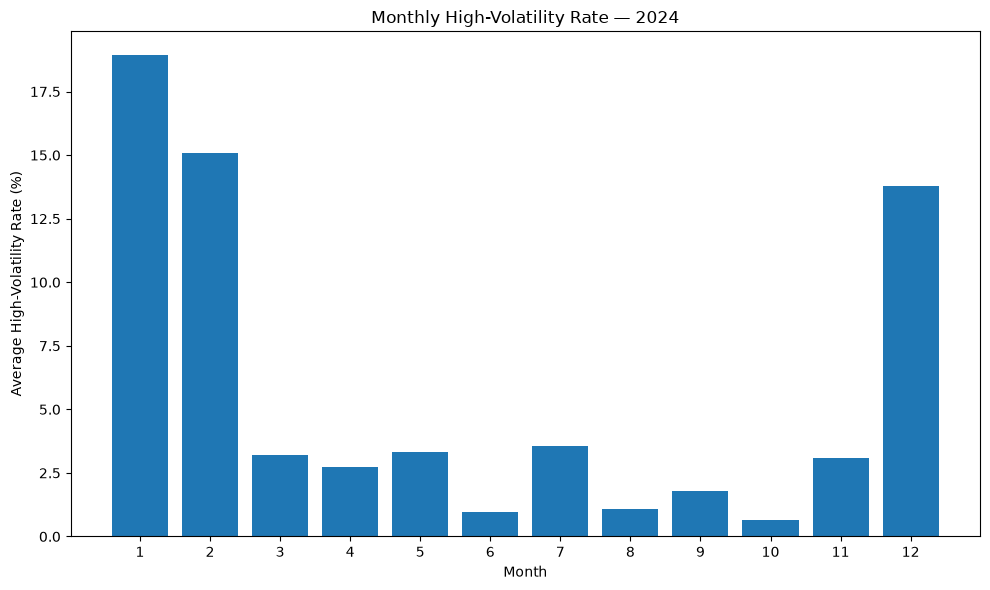

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(seasonal_pd["MONTH"],seasonal_pd["AVG_HIGH_VOLATILITY_RATE"] * 100)
plt.xlabel("Month")
plt.ylabel("Average High-Volatility Rate (%)")
plt.title("Monthly High-Volatility Rate — 2024")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [18]:
print("=== FINAL SUMMARY ===")
print("Daily records:", 26545)
print("Stations:", monthly_df.select("STATION").distinct().count())
print("Monthly records:", monthly_df.count())
print("Qualified station-months:", analysis_df.count())
print("Months:", monthly_df.select("MONTH").distinct().count())
print("High-volatility days:", 1537)

=== FINAL SUMMARY ===
Daily records: 26545
Stations: 79
Monthly records: 941
Qualified station-months: 903
Months: 12
High-volatility days: 1537
